# Mapping the Potential Destructive Power of Wildfires Using Machine Learning
---
## Module 4: *Variable Selection*
##### Version Number: 2.0
---
### Contents  
> 1. *Load Data*
> 2. *Water Demand Variables*
> 3. *Water Supply Variables*
> 4. *Geographic, Social, and Temporal Variables*
> 5. *Filter and Export File*
---
### Notes
- This module visualizes key environmental variables to assess their relationships with wildfire severity categories. Based on the `Categorical` target, we explore how different weather features interact and influence fire risk.
---
### Inputs
- `model_fire_pop_income.csv` cleaned weather data joined with cleaned fire damage dataset
- `details.csv` saved details associated with main dataset
---
### Outputs 
- `trimmed.csv` - trimmed weather and fire dataset
---
### User Defined Dependencies

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

# Function to print a grid of kde plots in consistent format, adjusts columns and rows accordingly
from src.plot_utils import grid_kde

# Function to print a custom format correlation heatmap
from src.plot_utils import correlation_map

---
### Third Party Dependencies

In [2]:
# Core data tools
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize

# Set consistent plotting style
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

---

## 1. Loading Data

In [3]:
details = pd.read_csv("../data/processed/details.csv")
filtered = pd.read_csv('../data/processed/model_fire_pop_income.csv')

In [4]:
filtered

,Unnamed: 0,Sample_ID,Date,Sample_Elevation,Region_ID,ETo (in),Precip (in),Sol Rad (Ly/day),Avg Vap Pres (mBars),Max Air Temp (F),...,Total Population,density,Mean Income,Target,Days Without Rain,2-Year Avg Fires,Avg Air Temp (F) 7 Day Avg,Precip (in) 7 Day Avg,Avg Rel Hum (%) 7 Day Avg,Avg Wind Speed (mph) 7 Day Avg
0,0,72,2021-12-23,68.172875,4,0.04,0.00,446.0,10.7,73.2,...,152682,109.889018,75449,0,1,37.0,43.828571,0.052857,87.142857,3.885714
1,1,159,2021-10-06,1484.432861,1,0.06,0.00,237.0,9.0,61.0,...,42905,6.834303,65853,0,1,245.0,55.371429,0.005714,51.714286,3.300000
2,2,19,2018-10-16,282.537201,6,0.15,0.00,449.0,9.5,74.1,...,2492442,345.861225,93563,0,13,153.0,62.814286,0.000000,56.571429,4.214286
3,3,54,2021-08-23,1138.741699,6,0.33,0.00,633.0,9.2,105.0,...,2195611,109.468892,85327,0,24,325.5,89.914286,0.000000,27.000000,6.657143
4,4,96,2023-03-22,3330.114014,4,0.07,0.11,273.0,9.6,59.0,...,479468,99.387673,72092,0,0,0.0,55.014286,0.154286,76.714286,3.328571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22141,22141,173,2021-08-01,1618.552856,1,0.25,0.00,622.0,10.4,93.2,...,8500,2.169602,59138,2,5,325.5,71.314286,0.005714,37.714286,4.257143
22142,22142,173,2022-09-02,1618.552856,1,0.31,0.00,602.0,5.7,98.4,...,8500,2.169602,59138,2,15,285.0,69.785714,0.000000,24.857143,4.928571
22143,22143,173,2024-06-26,1618.552856,1,0.31,0.00,718.0,10.0,82.8,...,8500,2.169602,59138,1,23,45.5,67.385714,0.000000,44.000000,4.371429
22144,22144,173,2024-07-08,1618.552856,1,0.29,0.00,711.0,9.5,99.8,...,8500,2.169602,59138,1,35,189.5,71.257143,0.000000,34.285714,3.300000


> ### Note  
> To reduce dataset size and simplify analysis, the following variables will be dropped:  
> - Dropped **Min** and **Max Air Temperature**, retained **Average Air Temperature**  
> - Dropped **Min** and **Max Relative Humidity**, retained **Average Relative Humidity**

In [5]:
## Master drop list for application at end of file
drop = ['Max Air Temp (F)','Min Air Temp (F)','Max Rel Hum (%)','Min Rel Hum (%)']

---

## 2. DIrect Water Demand Indicators

### 2.1 Water Demand Distribution Analysis

- `ETo (in)` - Evapotranspiration is a measure of how much water is lost to the atmosphere
- `Sol Rad (Ly/day)` - A measure of sunlight the soil has recieved in a day
- `Avg Air Temp (F)`- Elevated air temperatures increase vegetation dryness and boost fire intensity  
- `Avg Wind Speed (mph)` - Stronger winds accelerate fire spread and push embers further, creating spot fires 
- `Avg Soil Temp (F)` - Warm soils suggest extended dry periods; contribute to desiccated fuel beds  
- `Wind Run (miles)` - Total wind movement over time; influences how far and fast fires can travel

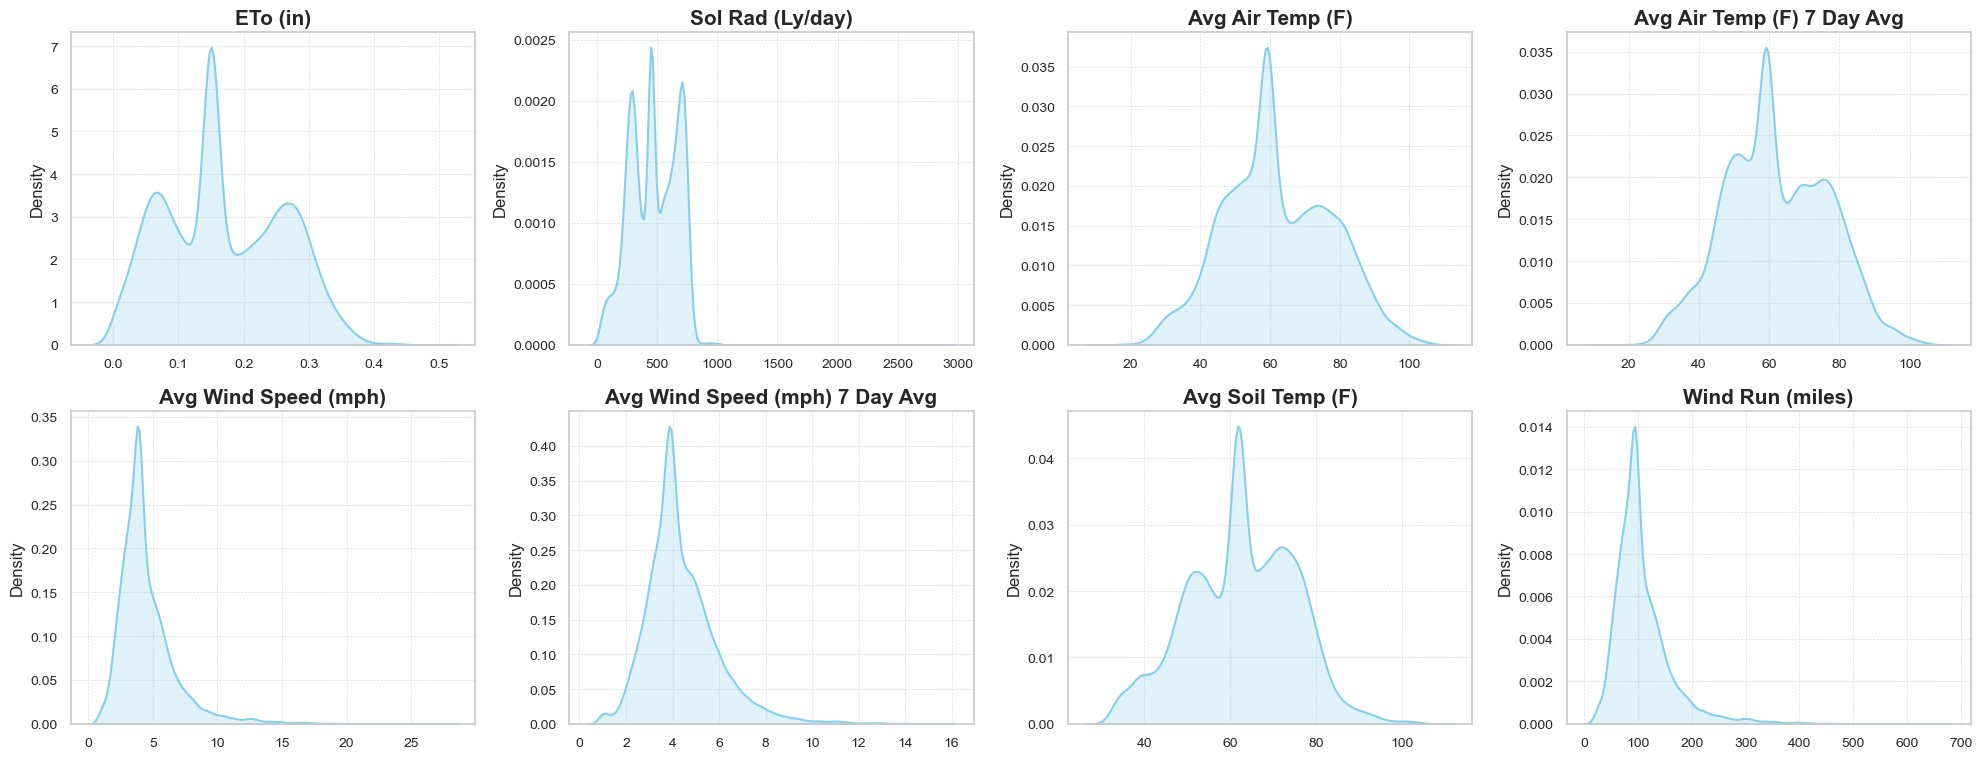

In [6]:
water_demand = ['ETo (in)', 'Sol Rad (Ly/day)', 'Avg Air Temp (F)', 'Avg Air Temp (F) 7 Day Avg',
                'Avg Wind Speed (mph)','Avg Wind Speed (mph) 7 Day Avg', 'Avg Soil Temp (F)','Wind Run (miles)','Target']

grid_kde(filtered[water_demand].drop(columns='Target'))

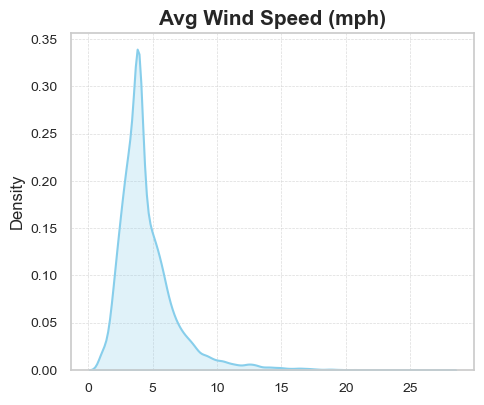

In [7]:
filtered['Avg Wind Speed (mph)'] = filtered['Avg Wind Speed (mph)'].clip(upper=30)

grid_kde(filtered[['Avg Wind Speed (mph)']])

### 2.2 Water Demand Correlation analysis

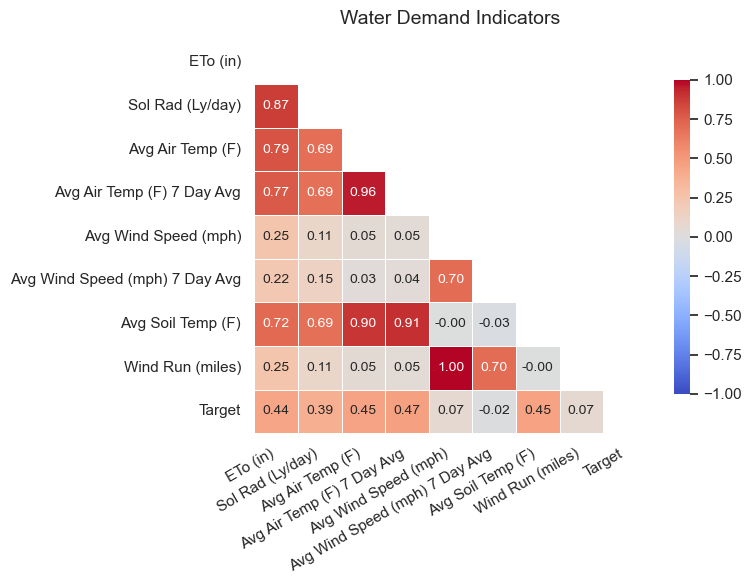

In [8]:
correlation_map(filtered[water_demand],'Water Demand Indicators')

#### Key Insights: Water Demand Variables

- **Evapotranspiration (ETo)** and **Solar Radiation** show a strong positive correlation, indicating shared influence from sunlight and temperature — both crucial in assessing vegetation moisture loss.
  
- **Dew Point** and **Vapor Pressure** are highly correlated, suggesting they provide overlapping information. These variables reflect atmospheric moisture content and may be redundant in modeling.

- Together, these indicators are effective in representing **vegetation dryness**, a critical factor in estimating wildfire ignition and spread potential.

- `ETO` and `Avg Vapor Pressure` are more correllated with target


### 2.3 Water Demand Colinearity analysis

<Axes: xlabel='ETo (in)', ylabel='Sol Rad (Ly/day)'>

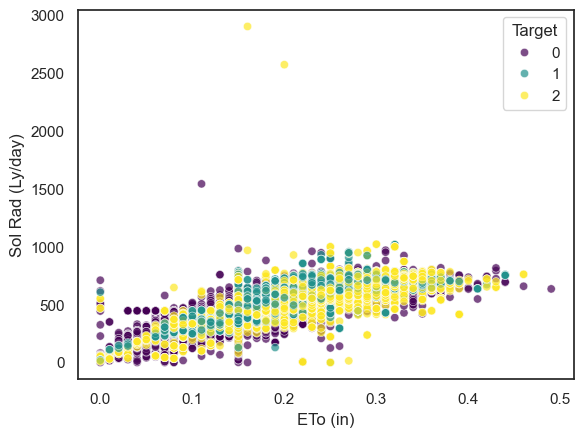

In [9]:
sns.scatterplot(
    x='ETo (in)', y='Sol Rad (Ly/day)', hue='Target', data=filtered, palette='viridis', alpha=0.7
)

<Axes: xlabel='Avg Wind Speed (mph)', ylabel='Wind Run (miles)'>

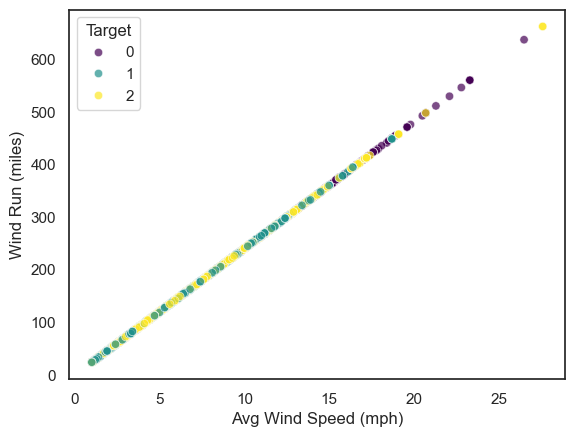

In [10]:
sns.scatterplot(
    x='Avg Wind Speed (mph)', y='Wind Run (miles)', hue='Target', data=filtered, palette='viridis', alpha=0.7
)

<Axes: xlabel='Avg Soil Temp (F)', ylabel='Avg Air Temp (F)'>

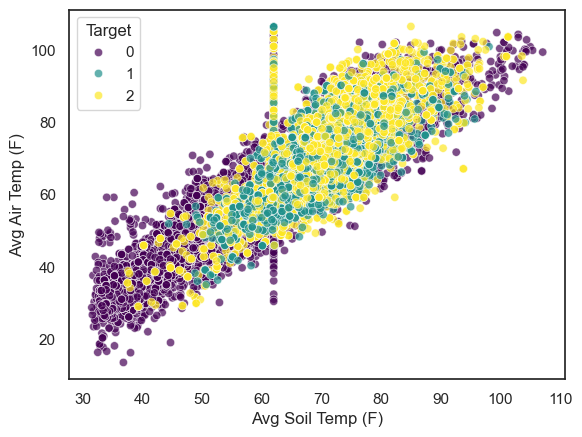

In [11]:
sns.scatterplot(
    x='Avg Soil Temp (F)', y='Avg Air Temp (F)', hue='Target', data=filtered, palette='viridis', alpha=0.7
)

### 2.4 Key Findings - Water Demand Indicators

- **Evapotranspiration (ETo)** and **Solar Radiation** showed a **strong positive correlation**, indicating that days with high solar energy also tend to have greater evaporative demand. This aligns with meteorological understanding and highlights both as valuable indicators of fuel dryness.
- **Average Wind Speed (mph)** and **Wind Run (miles)** show direct correlation, drop wind run and keep wind speed

In [12]:
drop.extend(['Wind Run (miles)'])
drop

['Max Air Temp (F)',
 'Min Air Temp (F)',
 'Max Rel Hum (%)',
 'Min Rel Hum (%)',
 'Wind Run (miles)']

---

## 3. Water Supply Indicators

### 3.1 Water Supply Distribution Analysis

- `Precip (in)` - Rainfall reduces wildfire risk by moistening vegetation and fuels; prolonged dryness increases flammability
- `Avg Rel Hum (%)` - Average relative humidity reflects how saturated the air is; lower values dry out fuels and promote ignition
- `Avg Vap Pres (mBars)` - Vapor pressure indicates moisture content in the air; lower pressure signals drier conditions favorable for fire spread  
- `Dew Point (F)` - The temperature at which air becomes saturated; lower dew points mean drier air, increasing fire potential 

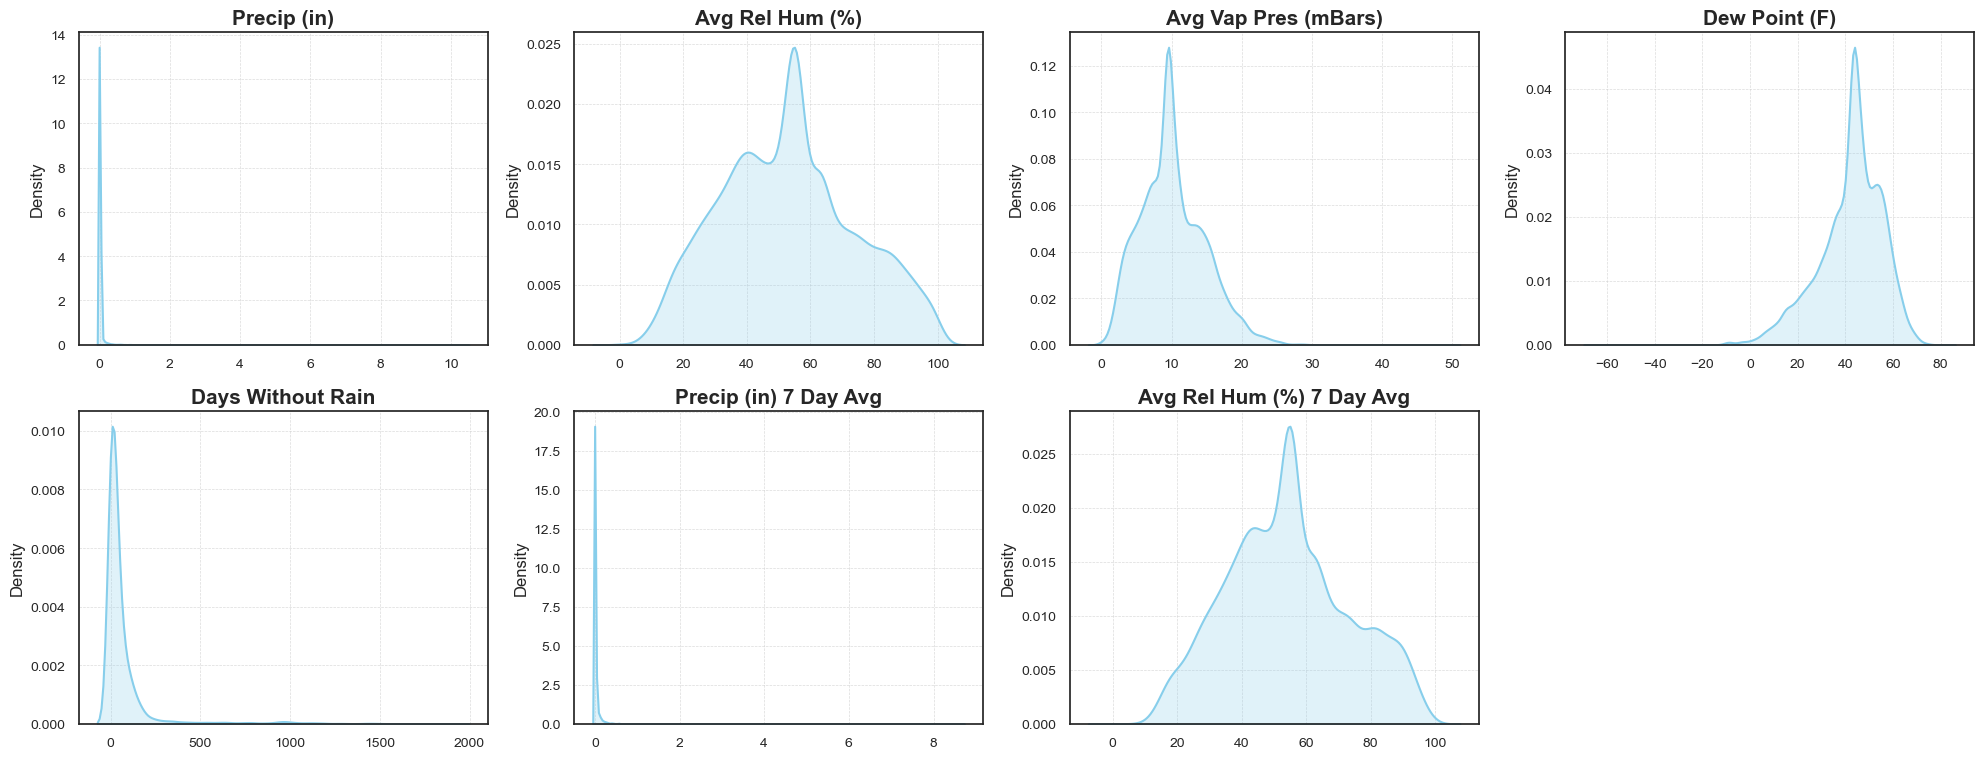

In [14]:
water_supply = ['Precip (in)', 'Avg Rel Hum (%)', 'Avg Vap Pres (mBars)', 'Dew Point (F)','Days Without Rain',
                'Precip (in) 7 Day Avg', 'Avg Rel Hum (%) 7 Day Avg', 'Target']
grid_kde(filtered[water_supply].drop(columns='Target'))

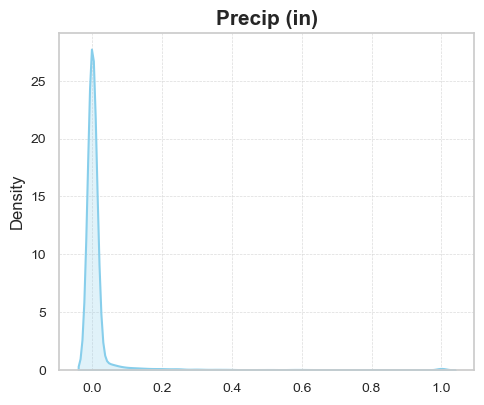

In [15]:
filtered['Precip (in)'] = filtered['Precip (in)'].clip(upper=1)
grid_kde(filtered[['Precip (in)']])

### 3.2 Water Supply Correlation Analysis

- **Inverse Relationship with Fire Severity**  
  Both precipitation and relative humidity indicators are **negatively correlated** with the categorical fire risk index. This aligns with domain expectations—**drier and less humid conditions correspond to higher wildfire severity**.

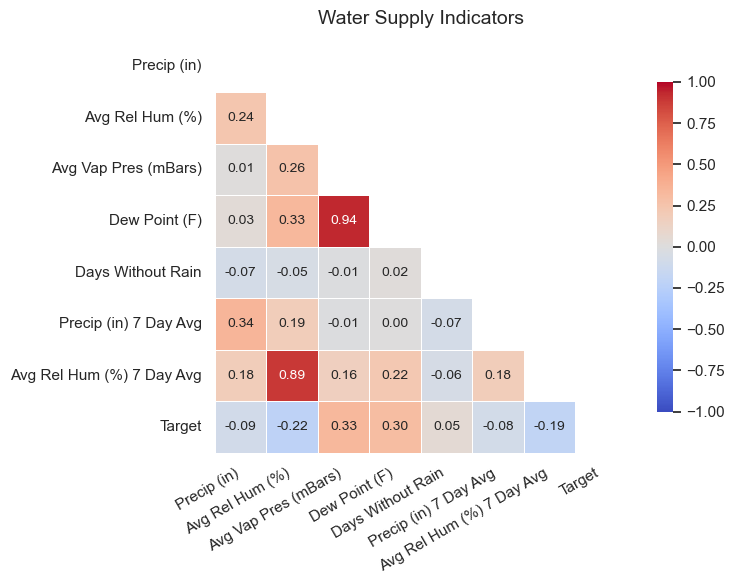

In [16]:
correlation_map(filtered[water_supply],'Water Supply Indicators')

### 3.3 Water Supply Colinearity Analysis

Drop `Dew Point (F)` due to **colinearity** with `Avg Vap Pres (mBars)` and less correlation with the target index

<Axes: xlabel='Avg Vap Pres (mBars)', ylabel='Dew Point (F)'>

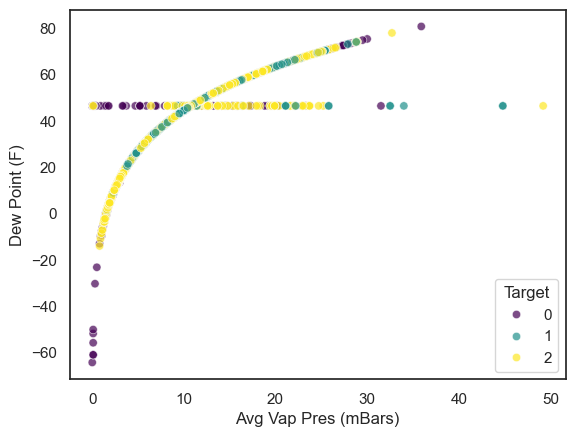

In [17]:
sns.scatterplot(
    x='Avg Vap Pres (mBars)', y='Dew Point (F)', hue='Target', data=filtered, palette='viridis', alpha=0.7
)

In [18]:
drop.extend(['Dew Point (F)'])

### 3.4 Water Supply Key Findings

---

## 4. Geographic, Social, and Temporal Variables
- Geographic, Social, and Temporal Variables

### 4.1 Geographic, Social, and Temporal Variables Distribution Analysis
- Social Indicators - `Total Population`, `Mean Income`, `density`
- Geographic Indicators - `Elevation`,`Region`
- Temporal Indicators - `Season`

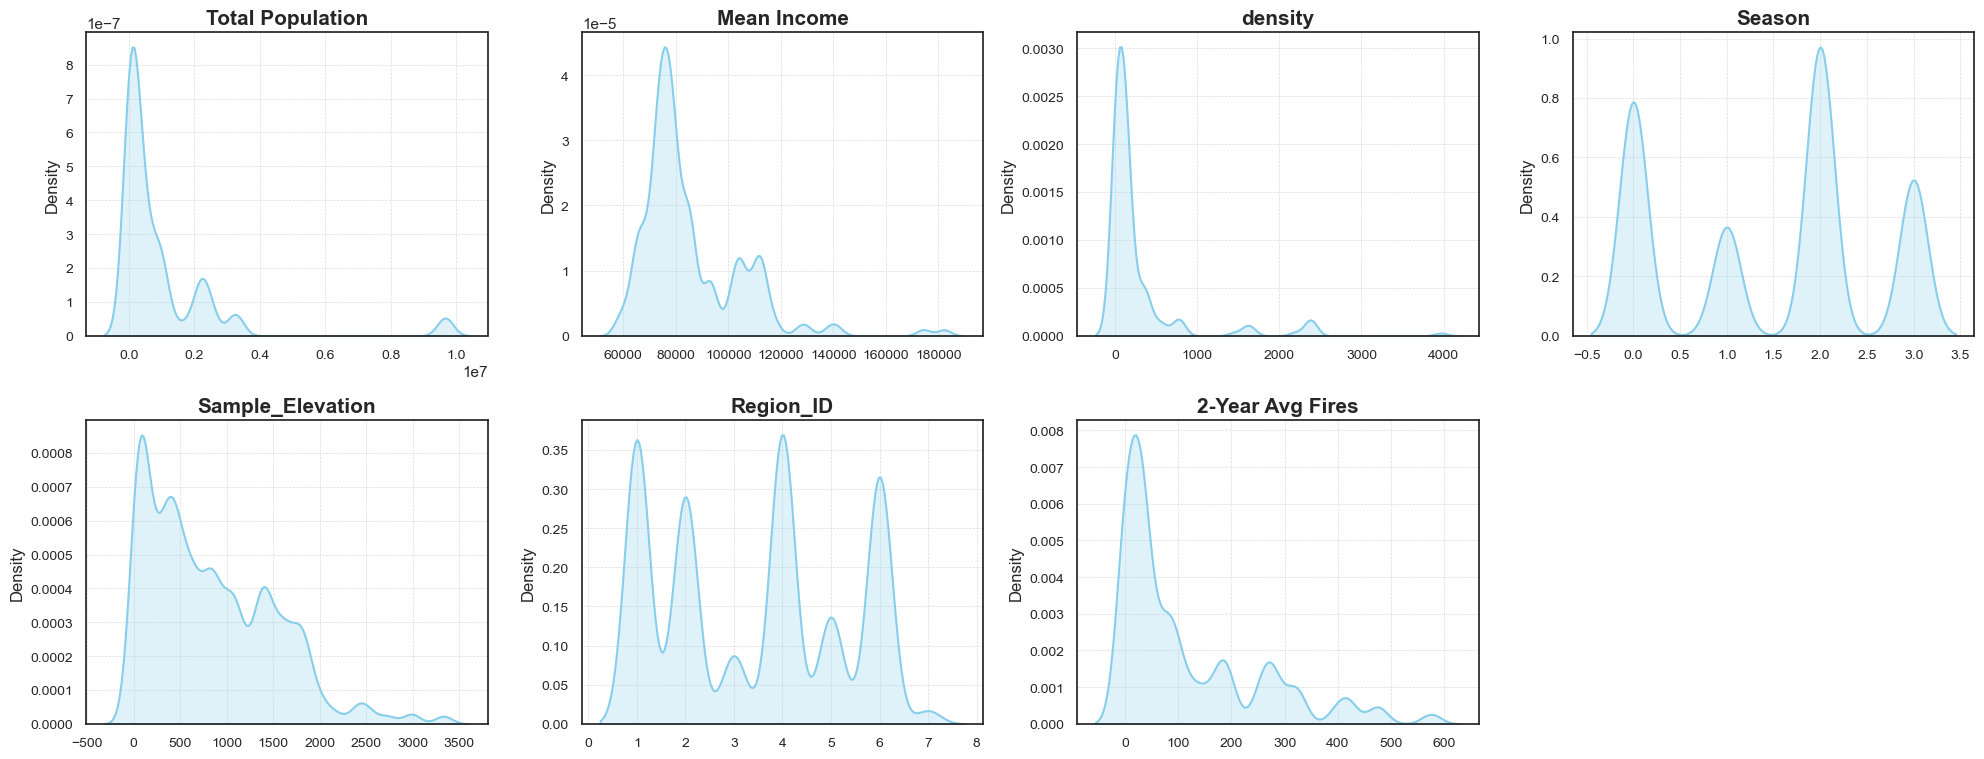

In [19]:
social = ['Total Population', 'Mean Income', 'density', 'Season', 
                'Sample_Elevation','Region_ID','2-Year Avg Fires', 'Target']
grid_kde(filtered[social].drop(columns='Target'))

### 4.2 Geographic, Social, and Temporal Variables Correlation Analysis

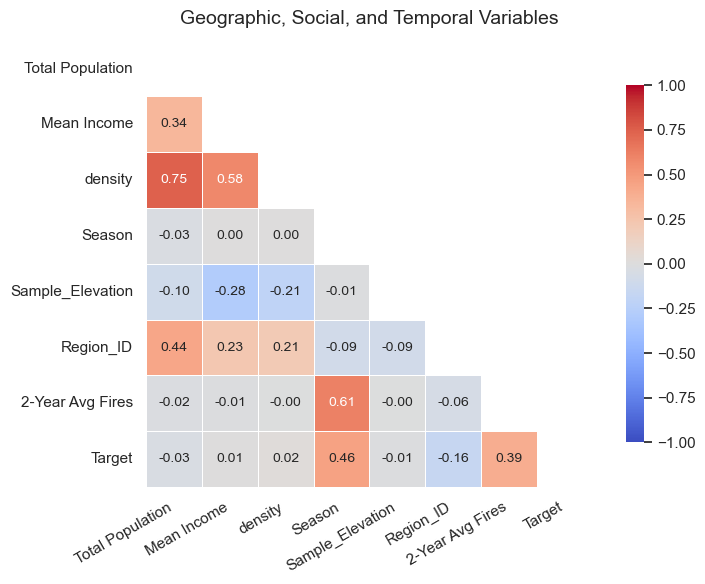

In [20]:
correlation_map(filtered[social],'Geographic, Social, and Temporal Variables')

### 4.3 Geographic, Social, and Temporal Variables Colinearity Analysis

### 4.4 Geographic, Social, and Temporal Variables Key Findings

---

## 5. Filter and Export 

In [21]:
selected = filtered.drop(columns = drop)
selected

,Unnamed: 0,Sample_ID,Date,Sample_Elevation,Region_ID,ETo (in),Precip (in),Sol Rad (Ly/day),Avg Vap Pres (mBars),Avg Air Temp (F),...,Total Population,density,Mean Income,Target,Days Without Rain,2-Year Avg Fires,Avg Air Temp (F) 7 Day Avg,Precip (in) 7 Day Avg,Avg Rel Hum (%) 7 Day Avg,Avg Wind Speed (mph) 7 Day Avg
0,0,72,2021-12-23,68.172875,4,0.04,0.00,446.0,10.7,59.2,...,152682,109.889018,75449,0,1,37.0,43.828571,0.052857,87.142857,3.885714
1,1,159,2021-10-06,1484.432861,1,0.06,0.00,237.0,9.0,50.8,...,42905,6.834303,65853,0,1,245.0,55.371429,0.005714,51.714286,3.300000
2,2,19,2018-10-16,282.537201,6,0.15,0.00,449.0,9.5,59.2,...,2492442,345.861225,93563,0,13,153.0,62.814286,0.000000,56.571429,4.214286
3,3,54,2021-08-23,1138.741699,6,0.33,0.00,633.0,9.2,90.6,...,2195611,109.468892,85327,0,24,325.5,89.914286,0.000000,27.000000,6.657143
4,4,96,2023-03-22,3330.114014,4,0.07,0.11,273.0,9.6,50.6,...,479468,99.387673,72092,0,0,0.0,55.014286,0.154286,76.714286,3.328571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22141,22141,173,2021-08-01,1618.552856,1,0.25,0.00,622.0,10.4,71.9,...,8500,2.169602,59138,2,5,325.5,71.314286,0.005714,37.714286,4.257143
22142,22142,173,2022-09-02,1618.552856,1,0.31,0.00,602.0,5.7,72.8,...,8500,2.169602,59138,2,15,285.0,69.785714,0.000000,24.857143,4.928571
22143,22143,173,2024-06-26,1618.552856,1,0.31,0.00,718.0,10.0,69.2,...,8500,2.169602,59138,1,23,45.5,67.385714,0.000000,44.000000,4.371429
22144,22144,173,2024-07-08,1618.552856,1,0.29,0.00,711.0,9.5,75.8,...,8500,2.169602,59138,1,35,189.5,71.257143,0.000000,34.285714,3.300000


In [22]:
selected.to_csv('../data/processed/trimmed.csv', index=False)
print("All datasets saved successfully to ../data/processed/")

All datasets saved successfully to ../data/processed/
